<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Actividad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Ejercicio: Tibasa**

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

<img src="https://lh3.googleusercontent.com/drive-storage/AJQWtBOpz22EVgDSbtaq1_4AhAFktO9ZNOvZ6xSwpYYgnAo1ycwBbobYvaRlSgGmxUcJqMpFvjOQhjkpT8MdE1dwLFVCISCBvzUNd8KbdO2S2B_0Uyo3bQ=w1852-h870?auditContext=forDisplay" width="600" height="300">

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

In [100]:
# Imoortamos las librerías
import random as r
import math
import matplotlib.pyplot as plt
from scipy.stats import norm

In [101]:
# Parámetros
a = 190
b = 230
c = 210
N = 10000

#**Solución Analítica:**
Usando el Torema de Límite Central
$$S ≈ N(\mu_s,\sigma_s)$$

In [102]:
#Para una triangular
mu= (a+b+c)/3  #Media
mu_s= 5*mu

sigma= ((a**2)+(b**2)+(c**2)-(a*b)-(a*c)-(b*c))/18    #Varianza
sigma_2= 5*sigma
sigma_s= math.sqrt(sigma_2)
print("S=N(",mu_s,sigma_s,")") #Obtenemos S

#Estandarizamos
z= (1000-mu_s)/sigma_s
print("z=",z)

#Resultado final
probabilidad_analitica = norm.cdf(z)
resultado_analitico = 1-probabilidad_analitica
print("Probabilidad analítica =",resultado_analitico)

S=N( 1050.0 18.257418583505537 )
z= -2.7386127875258306
Probabilidad analítica = 0.9969150503397279


#**Solución Simulación:**

### Paso 1: Definimos las variables.

Sea $$X_i: \text{Peso de cada tina} $$

Con $$X_i \sim \text{Triangular (a=190 kg, b=230 kg, c=210 kg)} $$

Aplicando transformación inversa distribución triangular:

$$ F(c) = \frac{c-a}{b-a}$$

con

$$
X = \begin{cases}
      a + \sqrt{R(b-a)(c-a)} & R \leq 0.5 \\
      b - \sqrt{(1-R)(b-a)(b-c)} & R > 0.5
   \end{cases}
$$

In [103]:
sumas=[] #Guardar sumas
excesos=0 #Contador de excesos
probabilidad=[] #Guardar probabilidades

for i in range(1,N+1):
    suma=0
    for j in range(5):
      R =r.random() #Generamos R uniforme
      Fc =(c - a)/(b - a) #Calculamos F(c)
      if R <= 0.5: #Triangular
        X = a + math.sqrt(R * (b - a) * (c - a))
      else:
        X = b - math.sqrt((1 - R) * (b - a) * (b - c))
      suma+=X
    sumas.append(suma)

    if suma > 1000:
        excesos+=1

#Probabilidad estimada
    p = excesos/i
    probabilidad.append(p)
print("Probabilidad estimada =",probabilidad[-1])


Probabilidad estimada = 0.9976


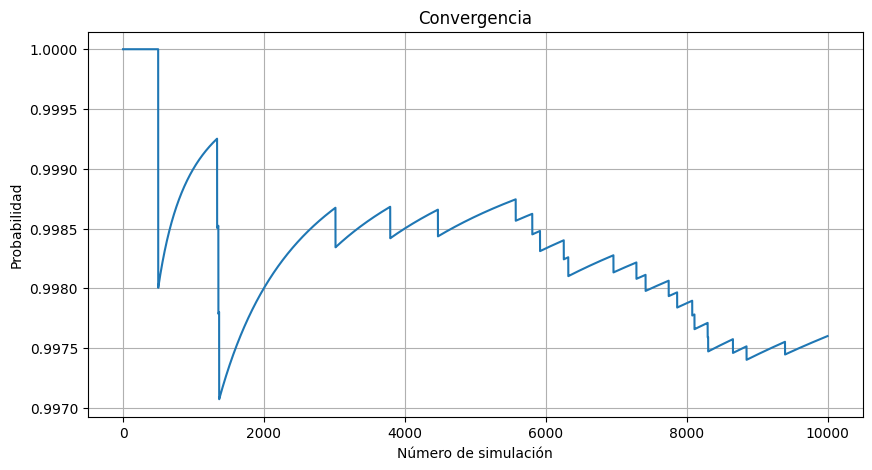

In [104]:
#Grafica de las simulaciones
plt.figure(figsize=(10,5))
plt.plot(probabilidad)
plt.xlabel("Número de simulación")
plt.ylabel("Probabilidad")
plt.title("Convergencia")
plt.grid()
plt.show()

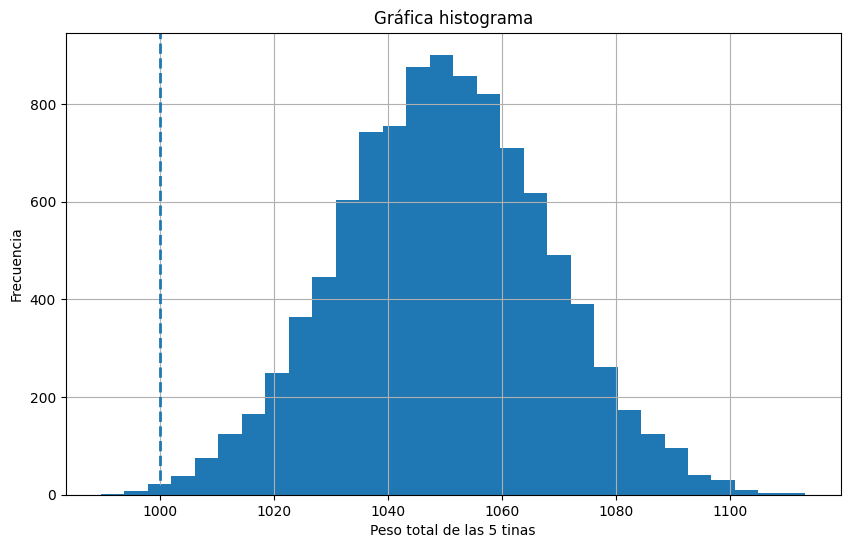

In [105]:
#Grafica histgrama
plt.figure(figsize=(10,6))
plt.hist(sumas,bins=30)
plt.axvline(1000, linestyle='--', linewidth=2) #Línea que marca el tope de capacidad
plt.xlabel("Peso total de las 5 tinas")
plt.ylabel("Frecuencia")
plt.title("Gráfica histograma")
plt.grid()
plt.show()